# Exploratory Data Analysis: Financial News Dataset
## Data Quality Assessment for Sentiment Analysis

**Objective:** Analyze the collected financial news data to ensure quality and prepare insights for sentiment analysis.

**Data Source:** Processed financial news data

**Date:** March 2026

**author:** CHMICHA hibat allah 

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Load Processed Data

In [14]:
DATA_PATH = "../data/processed/processed_financial_news.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded {len(df)} articles with {df.shape[1]} features")
else:
    print("Processed data not found. Run preprocessing first.")
    df = pd.DataFrame()

Loaded 264 articles with 27 features


## 3. Data Overview

In [15]:
print("Dataset Info:")
df.info()

print("\nFirst 3 rows:")
df.head(3)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  264 non-null    str    
 1   published              50 non-null     str    
 2   source                 264 non-null    str    
 3   url                    264 non-null    str    
 4   content                152 non-null    str    
 5   description            204 non-null    str    
 6   author                 87 non-null     str    
 7   collection_method      264 non-null    str    
 8   collection_feed        264 non-null    str    
 9   collected_at           264 non-null    str    
 10  cleaned_text           264 non-null    str    
 11  word_count             264 non-null    int64  
 12  sentence_count         264 non-null    int64  
 13  avg_word_length        264 non-null    float64
 14  financial_term_count   264 non-null    int64  
 15  mon

,title,published,source,url,content,description,author,collection_method,collection_feed,collected_at,cleaned_text,word_count,sentence_count,avg_word_length,financial_term_count,money_mentions,percentage_mentions,has_financial_content,year,month,day,day_of_week,hour,processing_date,data_quality_score,ready_for_analysis,original_file
0,Ramit Sethi Says 'I've Been Renting For 20 Yea...,2026-03-04 16:45:39+00:00,Yahoo Finance,https://finance.yahoo.com/news/ramit-sethi-say...,NaN,NaN,NaN,rss,Yahoo Finance,2026-03-04T17:05:57.519647,Ramit Sethi Says 'I've Been Renting For 20 Yea...,26,1,4.62,0,0,0,False,2026.0,3.0,4.0,Wednesday,16.0,2026-03-06,0.1456,False,raw_news_data.csv
1,AtaiBeckley (ATAI) to Initiate Phase 3 Depress...,2026-03-04 16:40:52+00:00,Yahoo Finance,https://finance.yahoo.com/news/ataibeckley-ata...,NaN,NaN,NaN,rss,Yahoo Finance,2026-03-04T17:05:57.519647,AtaiBeckley (ATAI) to Initiate Phase 3 Depress...,12,0,6.25,0,0,0,False,2026.0,3.0,4.0,Wednesday,16.0,2026-03-06,0.0672,False,raw_news_data.csv
2,Hertz Global (HTZ) Achieves $2B Profitability ...,2026-03-04 16:40:45+00:00,Yahoo Finance,https://finance.yahoo.com/news/hertz-global-ht...,NaN,NaN,NaN,rss,Yahoo Finance,2026-03-04T17:05:57.519647,Hertz Global (HTZ) Achieves $2B Profitability ...,10,0,7.00,1,1,0,True,2026.0,3.0,4.0,Wednesday,16.0,2026-03-06,0.2060,False,raw_news_data.csv


## 4. Missing Data Analysis

In [4]:
missing_data = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum().values,
    'missing_pct': (df.isnull().sum().values / len(df) * 100).round(1)
})
missing_data = missing_data[missing_data['missing_count'] > 0].sort_values('missing_count', ascending=False)

if len(missing_data) > 0:
    print("Missing Values:")
    print(missing_data.to_string(index=False))
else:
    print("No missing values found!")

Missing Values:
          column  missing_count  missing_pct
 collection_feed           1066         80.4
collection_query            260         19.6
          author            240         18.1
         content            112          8.4
     description             66          5.0


## 5. Source Distribution

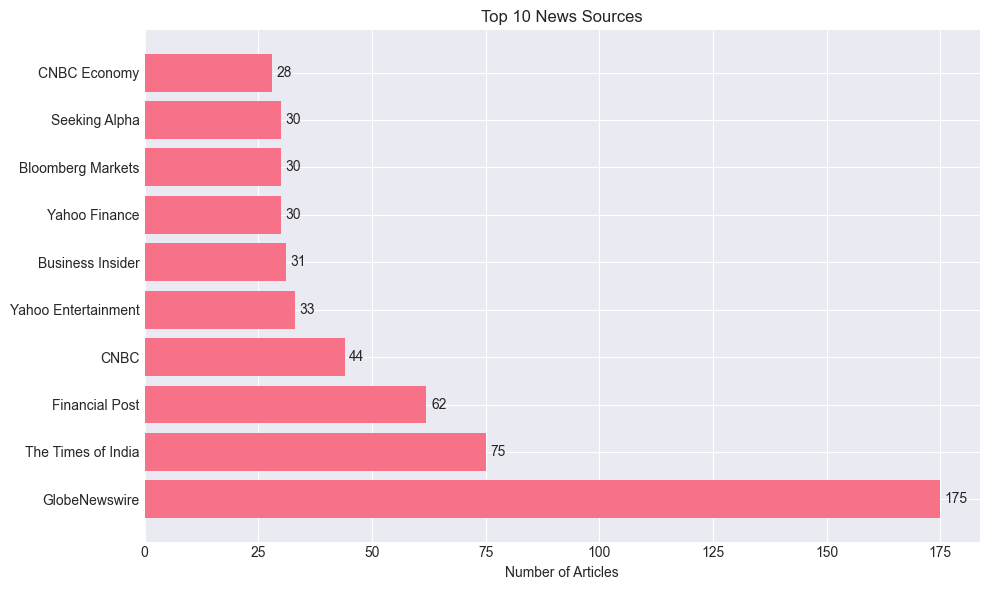

In [5]:
source_counts = df['source'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(source_counts)), source_counts.values)
plt.yticks(range(len(source_counts)), source_counts.index)
plt.xlabel('Number of Articles')
plt.title('Top 10 News Sources')

for i, v in enumerate(source_counts.values):
    plt.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()

## 6. Temporal Analysis

Articles with valid dates: 1116/1326


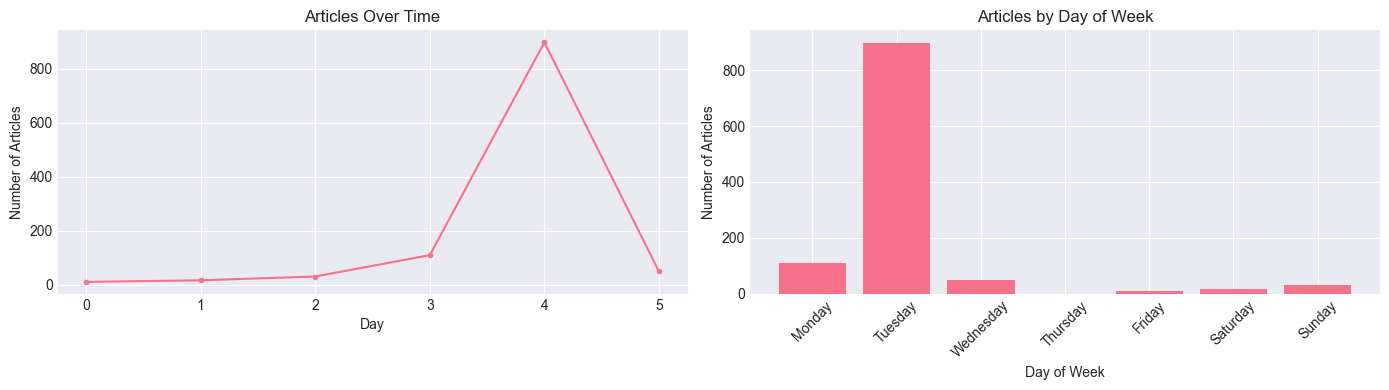

In [6]:
df['published_dt'] = pd.to_datetime(df['published'], errors='coerce')
df['date'] = df['published_dt'].dt.date
df['day_of_week'] = df['published_dt'].dt.day_name()

valid_dates = df['published_dt'].notna()
print(f"Articles with valid dates: {valid_dates.sum()}/{len(df)}")

if valid_dates.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Daily counts
    daily_counts = df[valid_dates].groupby('date').size()
    axes[0].plot(range(len(daily_counts)), daily_counts.values, marker='o', markersize=3)
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Number of Articles')
    axes[0].set_title('Articles Over Time')
    
    # Day of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df['day_of_week'].value_counts().reindex(day_order)
    axes[1].bar(day_counts.index, day_counts.values)
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Number of Articles')
    axes[1].set_title('Articles by Day of Week')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 7. Text Length Analysis

Article Length Statistics:
Mean: 50.3
Median: 33.0
Min: 3.0
Max: 3245.0
Very short (<20 words): 143
Long (>500 words): 23


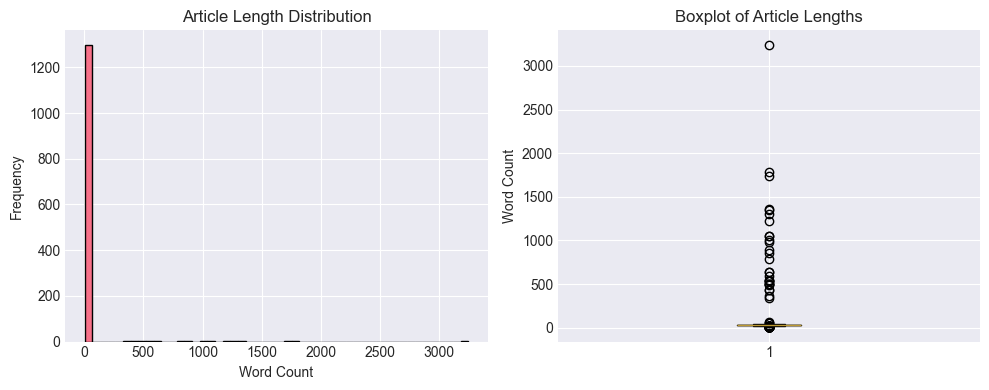

In [7]:
if 'word_count' in df.columns:
    print("Article Length Statistics:")
    print(f"Mean: {df['word_count'].mean():.1f}")
    print(f"Median: {df['word_count'].median():.1f}")
    print(f"Min: {df['word_count'].min()}")
    print(f"Max: {df['word_count'].max()}")
    print(f"Very short (<20 words): {(df['word_count'] < 20).sum()}")
    print(f"Long (>500 words): {(df['word_count'] > 500).sum()}")

    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['word_count'], bins=50, edgecolor='black')
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.title('Article Length Distribution')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df['word_count'])
    plt.ylabel('Word Count')
    plt.title('Boxplot of Article Lengths')
    
    plt.tight_layout()
    plt.show()

## 8. Financial Content Analysis

In [8]:
if 'has_financial_content' in df.columns:
    fin_count = df['has_financial_content'].sum()
    fin_pct = fin_count / len(df) * 100
    print(f"Articles with financial content: {fin_count} ({fin_pct:.1f}%)")

if 'financial_term_count' in df.columns:
    print(f"Avg financial terms per article: {df['financial_term_count'].mean():.2f}")
    print(f"Articles with 0 financial terms: {(df['financial_term_count'] == 0).sum()}")

if 'money_mentions' in df.columns:
    money_count = (df['money_mentions'] > 0).sum()
    print(f"Articles mentioning money: {money_count}")

if 'percentage_mentions' in df.columns:
    pct_count = (df['percentage_mentions'] > 0).sum()
    print(f"Articles mentioning percentages: {pct_count}")

Articles with financial content: 768 (57.9%)
Avg financial terms per article: 1.82
Articles with 0 financial terms: 558
Articles mentioning money: 122
Articles mentioning percentages: 104


## 9. Data Quality Assessment

Quality Score Stats:
Mean: 0.020
Median: 0.009
Min: 0.000
Max: 0.730


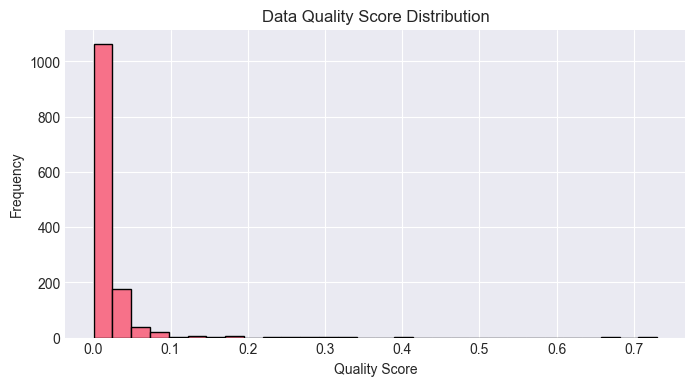

In [9]:
if 'data_quality_score' in df.columns:
    print(f"Quality Score Stats:")
    print(f"Mean: {df['data_quality_score'].mean():.3f}")
    print(f"Median: {df['data_quality_score'].median():.3f}")
    print(f"Min: {df['data_quality_score'].min():.3f}")
    print(f"Max: {df['data_quality_score'].max():.3f}")
    
    plt.figure(figsize=(8, 4))
    plt.hist(df['data_quality_score'], bins=30, edgecolor='black')
    plt.xlabel('Quality Score')
    plt.ylabel('Frequency')
    plt.title('Data Quality Score Distribution')
    plt.show()

In [10]:
if 'ready_for_analysis' in df.columns:
    ready_count = df['ready_for_analysis'].sum()
    ready_pct = (ready_count / len(df)) * 100
    print(f"Articles ready for sentiment analysis: {ready_count} ({ready_pct:.1f}%)")

    # Save filtered dataset
    filtered_df = df[df['ready_for_analysis'] == True].copy()
    output_path = "../data/processed/analysis_ready_articles.csv"
    os.makedirs("../data/processed", exist_ok=True)
    filtered_df.to_csv(output_path, index=False)
    print(f"Saved {len(filtered_df)} ready articles to: {output_path}")

Articles ready for sentiment analysis: 702 (52.9%)
Saved 702 ready articles to: ../data/processed/analysis_ready_articles.csv


## 10. Correlation Analysis

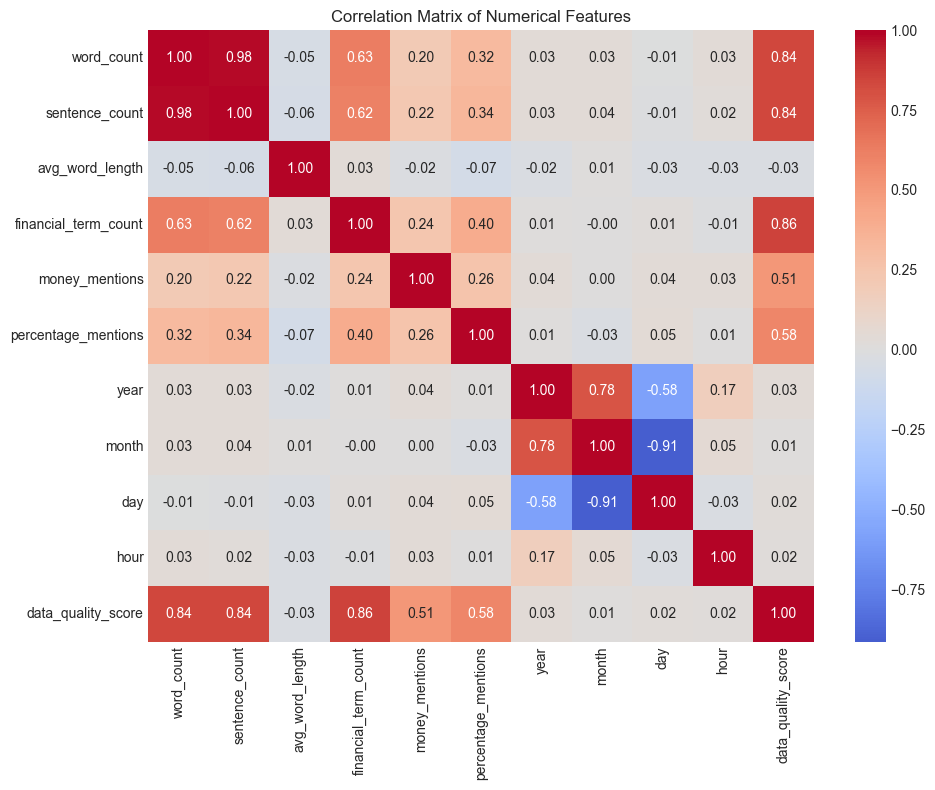

Strong Correlations (|r| > 0.7):
  word_count ↔ sentence_count: 0.983
  word_count ↔ data_quality_score: 0.838
  sentence_count ↔ data_quality_score: 0.835
  financial_term_count ↔ data_quality_score: 0.856
  year ↔ month: 0.785
  month ↔ day: -0.914


In [11]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numerical_cols) > 1:
    corr_matrix = df[numerical_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    
    print("Strong Correlations (|r| > 0.7):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

## 11. Source Quality Comparison

In [12]:
if 'source' in df.columns and 'ready_for_analysis' in df.columns:
    source_quality = df.groupby('source').agg({
        'title': 'count',
        'ready_for_analysis': 'mean',
        'word_count': 'mean',
        'financial_term_count': 'mean'
    }).round(2)
    source_quality.columns = ['article_count', 'ready_ratio', 'avg_words', 'avg_financial_terms']
    source_quality = source_quality[source_quality['article_count'] >= 5].sort_values('ready_ratio', ascending=False).head(10)
    
    print("Top Sources by Quality Ratio (min 5 articles):")
    print(source_quality.to_string())

Top Sources by Quality Ratio (min 5 articles):
                     article_count  ready_ratio  avg_words  avg_financial_terms
source                                                                         
Whatjapanthinks.com              5         1.00      30.60                 5.20
Fortune                         22         0.91     337.50                 9.00
CBS News                         9         0.89      34.89                 3.78
CoinDesk                         8         0.88      32.88                 2.12
Business Insider                31         0.87     632.00                10.42
Variety                          7         0.86      35.57                 1.14
GlobeNewswire                  175         0.81      32.31                 2.31
Ambcrypto.com                    5         0.80      36.00                 1.40
TheStreet                        5         0.80      35.80                 2.80
Crypto Briefing                  9         0.78      30.78               

## 12. Dataset Summary

In [13]:
print("=" * 50)
print("DATASET SUMMARY REPORT")
print("=" * 50)

print(f"\nTotal articles: {len(df)}")
print(f"Unique sources: {df['source'].nunique() if 'source' in df.columns else 'N/A'}")

if 'published_dt' in df.columns:
    valid_dates = df['published_dt'].dropna()
    if not valid_dates.empty:
        print(f"Date range: {valid_dates.min().date()} to {valid_dates.max().date()}")

if 'word_count' in df.columns:
    print(f"\nText Statistics:")
    print(f"  Avg words: {df['word_count'].mean():.1f}")
    print(f"  Median words: {df['word_count'].median():.1f}")
    print(f"  Short (<20 words): {(df['word_count'] < 20).sum()}")
    print(f"  Long (>500 words): {(df['word_count'] > 500).sum()}")

if 'has_financial_content' in df.columns:
    fin_count = df['has_financial_content'].sum()
    print(f"\nFinancial Relevance:")
    print(f"  Financial articles: {fin_count} ({fin_count/len(df)*100:.1f}%)")

if 'ready_for_analysis' in df.columns:
    ready_count = df['ready_for_analysis'].sum()
    print(f"\nReady for Analysis:")
    print(f"  Analysis-ready: {ready_count} ({ready_count/len(df)*100:.1f}%)")

print("\n" + "=" * 50)
print("EDA Complete - Dataset ready for sentiment analysis")

DATASET SUMMARY REPORT

Total articles: 1326
Unique sources: 316
Date range: 2026-02-27 to 2026-03-04

Text Statistics:
  Avg words: 50.3
  Median words: 33.0
  Short (<20 words): 143
  Long (>500 words): 23

Financial Relevance:
  Financial articles: 768 (57.9%)

Ready for Analysis:
  Analysis-ready: 702 (52.9%)

EDA Complete - Dataset ready for sentiment analysis
